In [196]:
print("Hi")

Hi


In [ ]:
import math

In [235]:
class Value:
    def __init__(self,data,_children = (),_op = '',label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda : None
        self._prev = set(_children)
        self._op = _op
        self.label = label


    def __repr__(self):
        return f"Value(data={self.data})"

    # Addition: -
    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data,(self,other),'+')
        def _backward():
            self.grad += 1 * out.grad
            other.grad += 1 * out.grad
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other


    # Multiplication: -
    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data,(self,other),'*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self*other


    #Negative ( -self)
    def __neg__(self):
        return self * -1

    # Subtraction: -
    def __sub__(self,other):
        return self + (-other)
    

    # Devision: -
    def __truediv__(self, other):
        return self*(other**-1)

    
    # Exponentiation : -
    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self,),"exp") 
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    
    # Power: -
    def __pow__(self,other):
        assert isinstance(other,(int,float))  # only support for int/float
        out = Value(self.data**other,(self,),f'**{other}')

        def _backward():
            self.grad += other*(self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out


    # tanh: -
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t,(self,),"tanh")

        def _backward():
            self.grad += (1- t**2)* out.grad
        out._backward = _backward
        
        return out

    
    # Backward past using toplogical sort : -
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


# a = Value(2.0,label='a')
# b = Value(3.0,label = 'b')
# a,b
# c = Value(-10.0,label = 'c')
# # a.__add__(b)
# k = a*b ; k.label = 'k'
# d = k + c ; d.label = 'd'
# f = Value(-2.0,label = 'f')
# L = d*f; L.label = "L"
# print(L)
# print(L._prev)
# print(L._op)

In [199]:
a = Value(2.0,label='a')
b = Value(3.0,label = 'b')

In [200]:
a.exp()

Value(data=7.38905609893065)

In [201]:
a / b

Value(data=0.6666666666666666)

In [202]:
a - b

Value(data=-1.0)

In [203]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

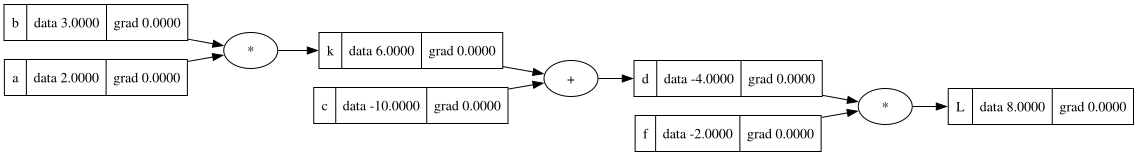

In [204]:
draw_dot(L)

differentiating \
L = f*d \
dL/dd = f \
dL/df = d \
 
dL/dd = -2 \
dL/df = -4

In [205]:
L.grad = 1.0
f.grad = -4
d.grad = -2.0

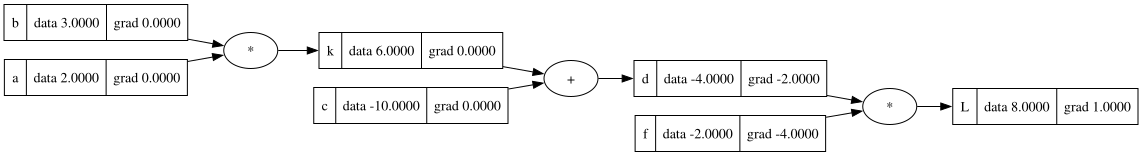

In [206]:
draw_dot(L)

Now we want to obtain : - \
\
dL/dc = ? \
dL/dK = ? \
\
We Know : \
\
dL/dc = (dL/dd)*(dd/dc)  \
\
d = k+c \
L = f*d \
dd/dc = 1 \
dd/dk = 1 \
dL/dd = -2 

\
dL/dc = -2 * 1 = -2 \
dL/dk = -2 * 1 = -2 

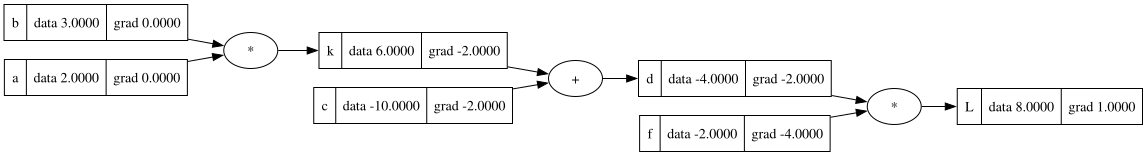

In [207]:
c.grad = -2
k.grad = -2

draw_dot(L)

Now we want to obtain : - \
\
dL/da = ? \
dL/db = ? \
\
We Know : \
\
dL/da = (dL/dd)(dd/dc)*(dc/da)  \
dL/db = (dL/dd)(dd/dc)*(dc/db)  \
\
k = a*b \
dc/da = b \
dd/db = a \

\
dL/da= 3 * 1 * -2  = -6 \
dL/db= 2 * 1 * -2  = -4

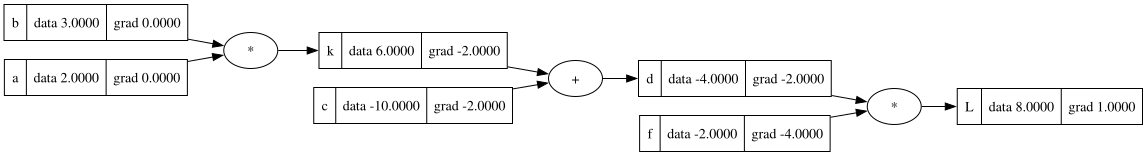

In [208]:
a.grad = -6
b.grad = -4

draw_dot(L)

In [209]:
def lol():
    h = 0.001
    a = Value(2.0,label='a')
    b = Value(3.0,label = 'b')
    c = Value(-10.0,label = 'c')
    k = a*b ; k.label = 'k'
    d = k + c ; d.label = 'd'
    f = Value(-2.0,label = 'f')
    L = d*f; L.label = "L"
    L1 = L.data


    a = Value(2.0,label='a')
    # a.data +=h
    b = Value(3.0,label = 'b')
    b.data +=h

    c = Value(-10.0,label = 'c')
    # c.data += h
    k = a*b ; k.label = 'k'
    d = k + c ; d.label = 'd'
    # d.data +=h
    f = Value(-2.0,label = 'f')
    # f.data +=h
    L = d*f; L.label = "L"
    L2 = L.data

    print((L2-L1)/h)

lol()

-3.9999999999995595


**Make a small neural network:-**

z = wx+b \

activation(z)

Value(data=0.9836748576936802)


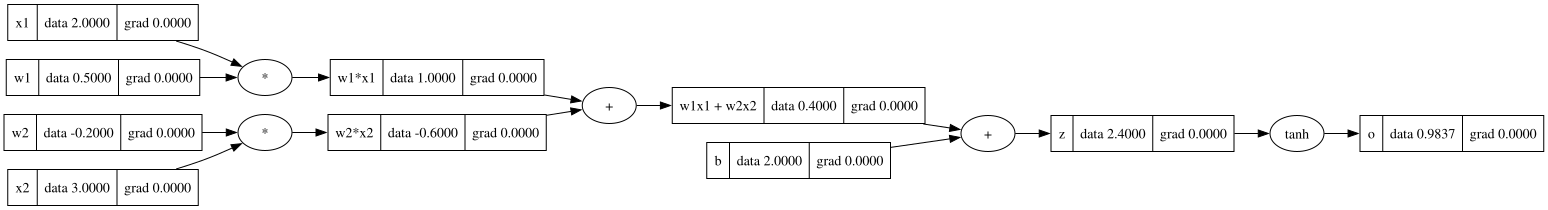

In [210]:
x1 = Value(2.0,label="x1")
x2 = Value(3.0,label="x2")

w1 = Value(0.5,label = "w1")
w2 = Value(-0.2,label = "w2")

b = Value(2.0,label = "b")

w1x1 = w1*x1 ;w1x1.label = "w1*x1"
w2x2 = w2*x2 ;w2x2.label = "w2*x2"

W = w1x1 + w2x2 ; W.label = "w1x1 + w2x2"
z = W + b ; z.label = "z"
o = z.tanh(); o.label = "o"
print(o)
draw_dot(o)

do/dz = 1-(tanh)^2

0.032383774341317895


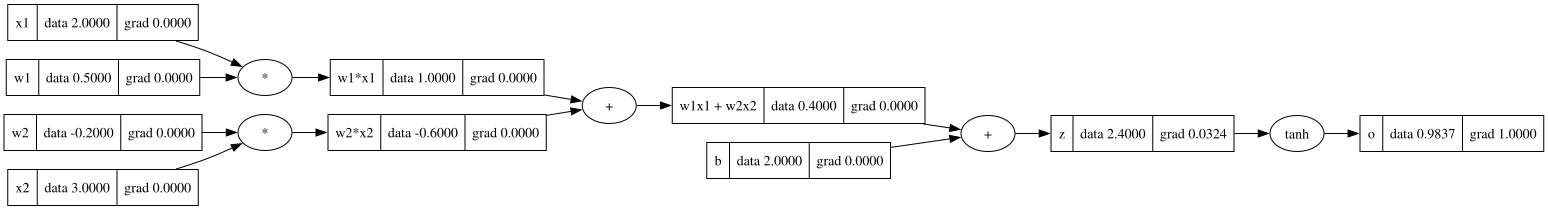

In [211]:
o.grad = 1.0
z.grad = 1 - (z.tanh().data)**2
print(z.grad)
draw_dot(o)

do/db = dz/db * do/dz   \
do/dW = dz/dW * do/dz   


do/db = do/dz = 1-(tanh(z))^2 = 0.0324

dz/db = ?
dz/dW = ?

z = Wx+b   \
dz/dW = dz/db = 1

do/db = 1 * 0.0324 = 0.0324  \
do/dW = 1 * 0.0324 = 0.0324


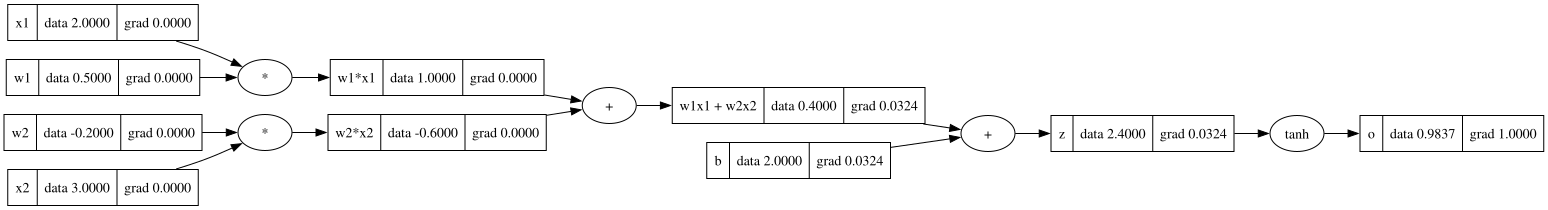

In [212]:
W.grad = 0.0324
b.grad = 0.0324
draw_dot(o)

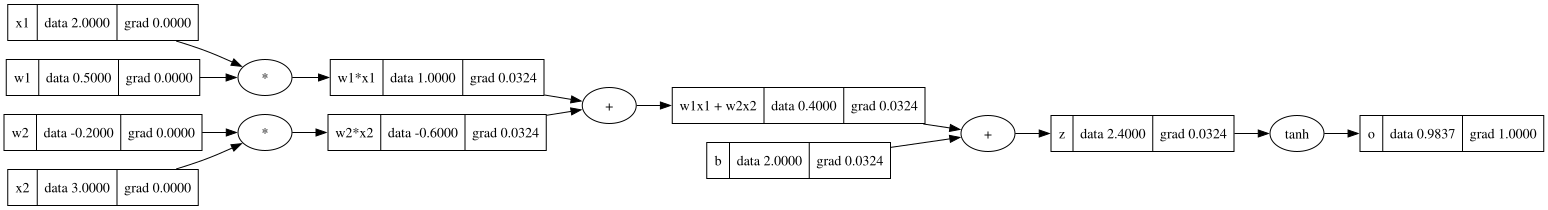

In [213]:
w1x1.grad = 0.0324
w2x2.grad = 0.0324
draw_dot(o)

0.0648


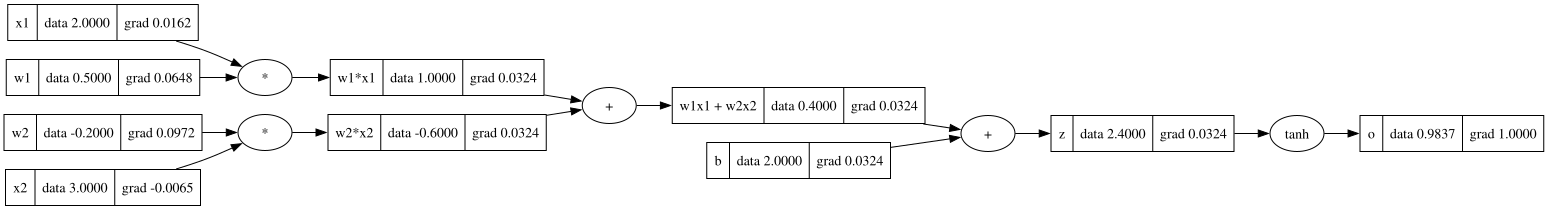

In [214]:
w1.grad = (x1.data) * (w1x1.grad)
print(w1.grad)
x1.grad = (w1.data) * (w1x1.grad)
w2.grad = (x2.data) * (w2x2.grad)
x2.grad = (w2.data) * (w2x2.grad)
draw_dot(o)

In [215]:
h = 0.001
x1 = Value(2.0,label="x1")
x2 = Value(3.0,label="x2")
w1 = Value(0.5,label = "w1")
w2 = Value(-0.2,label = "w2")

b = Value(2.0,label = "b")

w1x1 = w1*x1 ;w1x1.label = "w1*x1"
w2x2 = w2*x2 ;w2x2.label = "w2*x2"

W = w1x1 + w2x2 ; W.label = "w1x1 + w2x2"
z = W + b ; z.label = "z"
o = z.tanh(); o.label = "o"
L1 = o.data
print(L1)


x1 = Value(2.0,label="x1")
x2 = Value(3.0,label="x2")

w1 = Value(0.5,label = "w1")
w2 = Value(-0.2,label = "w2")
w1.data +=h

b = Value(2.0,label = "b")

w1x1 = w1*x1 ;w1x1.label = "w1*x1"
w2x2 = w2*x2 ;w2x2.label = "w2*x2"

W = w1x1 + w2x2 ; W.label = "w1x1 + w2x2"
# b.data += h
z = W + b ; z.label = "z"
# z.data += h
o = z.tanh(); o.label = "o"

L2 = o.data
print(L2)
print((L2 - L1)/h)

0.9836748576936802
0.9837394979861149
0.06464029243469227


### Auto mate Backward Pass:-

Value(data=0.9836748576936802)


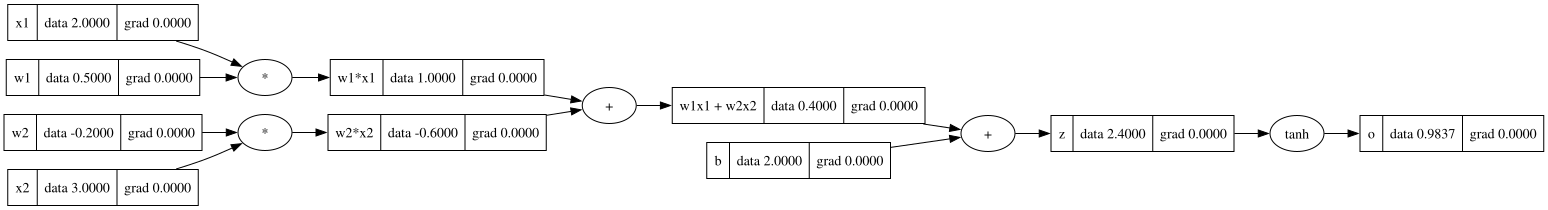

In [216]:
x1 = Value(2.0,label="x1")
x2 = Value(3.0,label="x2")

w1 = Value(0.5,label = "w1")
w2 = Value(-0.2,label = "w2")

b = Value(2.0,label = "b")

w1x1 = w1*x1 ;w1x1.label = "w1*x1"
w2x2 = w2*x2 ;w2x2.label = "w2*x2"

W = w1x1 + w2x2 ; W.label = "w1x1 + w2x2"
z = W + b ; z.label = "z"
o = z.tanh(); o.label = "o"
print(o)
draw_dot(o)

In [217]:
# o.grad = 1.0

In [218]:
# o._backward()

In [219]:
# z._backward()

In [220]:
# W._backward()

In [221]:
# w2x2._backward()

In [222]:
# w1x1._backward()

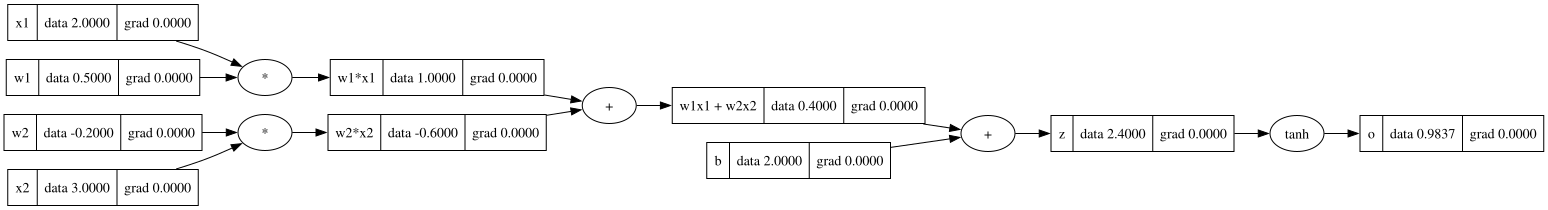

In [223]:

draw_dot(o)

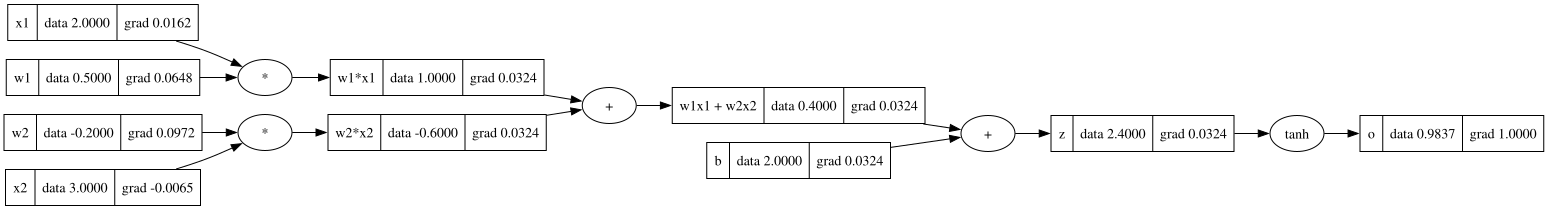

In [224]:
o.backward()
draw_dot(o)

Pass Backward in one line : -

In [225]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data=2.0),
 Value(data=3.0),
 Value(data=-0.2),
 Value(data=-0.6000000000000001),
 Value(data=2.0),
 Value(data=0.5),
 Value(data=1.0),
 Value(data=0.3999999999999999),
 Value(data=2.4),
 Value(data=0.9836748576936802)]

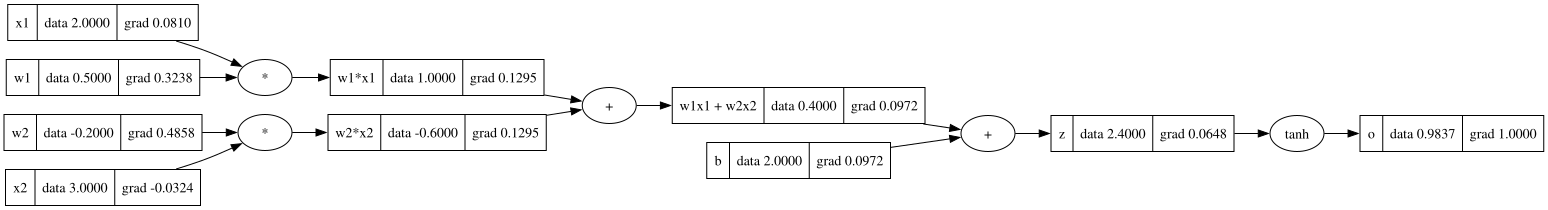

In [226]:
o.grad = 1
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)

for node in reversed(topo):
    node._backward()

draw_dot(o)

Mulivarient problem (means same variabel comes more than once in derrivative)

because of having the same variable it overides each other 

To solve the above problem of mulivarient we add the derivatieves

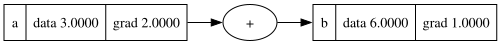

In [227]:
a = Value(3.0,label="a")
# b = Value(-2,label="b")
b = a + a ; b.label = 'b'
b.backward()
draw_dot(b)

In [228]:
1.0 + a

Value(data=4.0)

Value(data=0.9836748576936802)


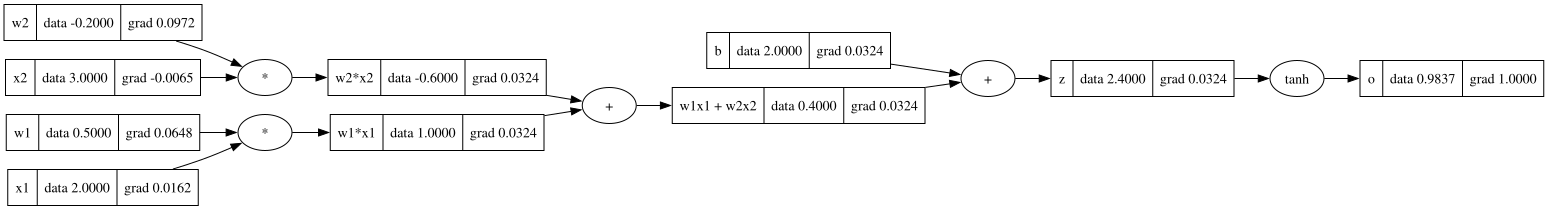

In [231]:
x1 = Value(2.0,label="x1")
x2 = Value(3.0,label="x2")

w1 = Value(0.5,label = "w1")
w2 = Value(-0.2,label = "w2")

b = Value(2.0,label = "b")

w1x1 = w1*x1 ;w1x1.label = "w1*x1"
w2x2 = w2*x2 ;w2x2.label = "w2*x2"

W = w1x1 + w2x2 ; W.label = "w1x1 + w2x2"
z = W + b ; z.label = "z"
o = z.tanh(); o.label = "o"
print(o)
o.backward()
draw_dot(o)

Now changing tanh inot its simpler form:

tanh = (e^2x - 1)/( e^2x + 1)                  

Value(data=0.9836748576936801)


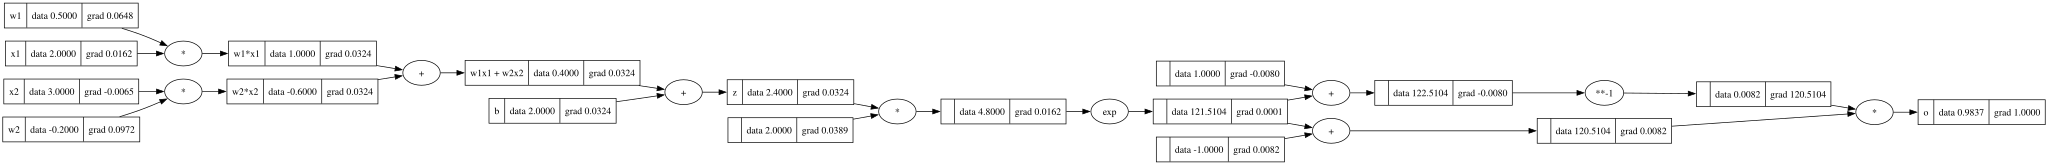

In [236]:
x1 = Value(2.0,label="x1")
x2 = Value(3.0,label="x2")

w1 = Value(0.5,label = "w1")
w2 = Value(-0.2,label = "w2")

b = Value(2.0,label = "b")

w1x1 = w1*x1 ;w1x1.label = "w1*x1"
w2x2 = w2*x2 ;w2x2.label = "w2*x2"

W = w1x1 + w2x2 ; W.label = "w1x1 + w2x2"
z = W + b ; z.label = "z"
# o = z.tanh(); o.label = "o"

e = (2*z).exp()
o = (e - 1)/(e + 1) ; o.label = 'o'
print(o)
o.backward()
draw_dot(o)